# Phase 1 — Step 1: Dataset Load & Initial EDA
**Project:** Elder Abuse Detection & Legal Assistance — CSE 499A, NSU Spring 2026  
**Dataset:** `data/Elder_abuse_Dataset.csv` (199 cases)

---

## Cell 1 — Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded ✅')

Libraries loaded ✅


## Cell 2 — Dataset Load

In [2]:
df = pd.read_csv('../data/Elder_abuse_Dataset.csv', encoding='utf-8')

print(f'Total rows    : {len(df)}')
print(f'Total columns : {len(df.columns)}')
print()
df.head()

Total rows    : 199
Total columns : 12



,Data Type,Date,Source,Location,Abuse Relation,Abuse Category,Gender,Name,Age,Scenerio(Bangla),Scenerio(English),URL / Source type
0,Secondary (News),"13 February , 2022",jugantor.com,Dhaka,Family,Neglect,Male,Abu Mohsin Khan,Unknown,পরিবারের অবহেলার কারণে আবু মহসিন আত্মহত্যা করে...,Abu Mohsin did suicide because his family negl...,https://www.jugantor.com/tp-ub-editorial/519945
1,Secondary (News),"26 February ,2024",jugantor.com,Dhaka,Children,Physical,Female,Khurshida Khatun,Unknown,মা তার ছেলেদের দ্বারা শারীরিক নির্যাতনের শিকার...,Mother was physically abused by her sons,https://www.jugantor.com/capital/778487
2,Secondary (News),"21 May , 2024",jugantor.com,Sherpur,Son,Financial Exploitation and physical,Female,Alpona Begum,45,পারিবারিক খরচের জন্য জমি লিখিয়ে নিতে মায়ের প...,Son breaks mother's leg after asking for money...,https://www.jugantor.com/country-news/807701
3,Secondary (News),"24 december , 2024",jagonews24.com,Shariyatpur,Children,Abandonment,Male,Sakib Ali Sardar,Unknown,জঙ্গলে পরিত্যক্ত এক অসুস্থ বৃদ্ধের শেষ পরিণতি ...,Sick old man abandoned in forest ends up in ol...,https://www.jagonews24.com/country/news/990195
4,Secondary (News),"23 February , 2023",prothomalo.com,Noakhali,Neighbors,Physical,Female,Anonymous,40,টিকটকে মা ও মেয়েকে বেঁধে নির্যাতন করার ভিডিও ...,Case filed over video of mother and daughter t...,https://www.prothomalo.com/bangladesh/district...


## Cell 3 — Column Names

In [3]:
print('All Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

All Columns:
   1. Data Type
   2. Date
   3. Source
   4. Location
   5. Abuse Relation
   6. Abuse Category
   7. Gender
   8. Name
   9. Age
  10. Scenerio(Bangla)
  11. Scenerio(English)
  12. URL / Source type


## Cell 4 — Data Types & Basic Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Data Type          199 non-null    str  
 1   Date               199 non-null    str  
 2   Source             199 non-null    str  
 3   Location           199 non-null    str  
 4   Abuse Relation     199 non-null    str  
 5   Abuse Category     199 non-null    str  
 6   Gender             199 non-null    str  
 7   Name               199 non-null    str  
 8   Age                199 non-null    str  
 9   Scenerio(Bangla)   199 non-null    str  
 10  Scenerio(English)  199 non-null    str  
 11  URL / Source type  199 non-null    str  
dtypes: str(12)
memory usage: 18.8 KB


## Cell 5 — Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

if missing_df.empty:
    print('No missing values found ✅')
else:
    print('Columns with missing values:')
    print(missing_df.to_string())

No missing values found ✅


## Cell 6 — Abuse Category (Raw)

In [6]:
# Find the abuse category column (handle slight name differences)
cat_col = [c for c in df.columns if 'abuse' in c.lower() and 'category' in c.lower()]
cat_col = cat_col[0] if cat_col else 'Abuse Category'

print(f'Column used: "{cat_col}"')
print()
counts = df[cat_col].value_counts()
print(counts.to_string())

Column used: "Abuse Category"

Abuse Category
Abandonment                                         45
Neglect                                             32
Financial Exploitation and physical                 20
Physical                                            19
Physical                                            16
Murder                                              14
Verbally                                            13
Neglect and Abandonment                             12
Financial Exploitation and Abandonment               8
Verbally                                             4
Financial Exploitation                               3
Abandonment and physical                             3
Neglect                                              2
Financial Exploitation, physical and abandonment     1
Physcial                                             1
Physical Abuse                                       1
Financial Exploitation and Murder                    1
Financial Exploitat

## Cell 7 — Abuse Relation (Who is the Abuser?)

In [7]:
rel_col = [c for c in df.columns if 'relation' in c.lower() or 'abuser' in c.lower()]
rel_col = rel_col[0] if rel_col else 'Abuse Relation'

print(f'Column used: "{rel_col}"')
print()
rel_counts = df[rel_col].value_counts()
print(rel_counts.to_string())

# Trust Blind Spot: family members as abusers
family_keywords = ['son', 'daughter', 'spouse', 'husband', 'wife',
                   'child', 'ছেলে', 'মেয়ে', 'স্বামী', 'স্ত্রী']
family_mask = df[rel_col].str.lower().str.contains(
    '|'.join(family_keywords), na=False
)
trust_pct = family_mask.sum() / len(df) * 100
print(f'\nTrust Blind Spot (family member abusers): {family_mask.sum()} cases = {trust_pct:.1f}%')

Column used: "Abuse Relation"

Abuse Relation
Son                                   72
Children                              39
Son and daughter-in-law               27
Family                                17
Daughter-in-law                        8
Relative                               8
Daughter                               4
Nephew and his wife                    2
Grand son                              2
Neighbor                               2
Son                                    2
son                                    2
Neighbors                              1
Younger Brother                        1
Union Council Member                   1
Police                                 1
Wife and Children                      1
Son, daughter-in-law and grand son     1
Son-in-law and Grand son               1
Son and Grand son                      1
Husband and daughter-in-law            1
Landlord                               1
Homemaid                               1
Unknown    

## Cell 8 — Gender Distribution

In [8]:
gen_col = [c for c in df.columns if 'gender' in c.lower()]
gen_col = gen_col[0] if gen_col else 'Gender'

print(f'Column used: "{gen_col}"')
print(df[gen_col].value_counts().to_string())

Column used: "Gender"
Gender
Male             103
Female            82
Male & Female     14


## Cell 9 — Data Source Type

In [9]:
type_col = [c for c in df.columns if 'data' in c.lower() and 'type' in c.lower()]
type_col = type_col[0] if type_col else 'Data Type'

print(f'Column used: "{type_col}"')
print(df[type_col].value_counts().to_string())

Column used: "Data Type"
Data Type
Primary (Interview)      104
Secondary (News)          72
Secondary(Interview)      16
Secondary (Interview)      5
primary (Interview)        2


## Cell 10 — Age Distribution (Raw)

In [10]:
age_col = [c for c in df.columns if 'age' in c.lower()]
age_col = age_col[0] if age_col else 'Age'

print(f'Column used: "{age_col}"')
print(f'Sample values: {df[age_col].head(10).tolist()}')
print(f'Unique value count: {df[age_col].nunique()}')

# Try numeric conversion
age_numeric = pd.to_numeric(df[age_col], errors='coerce')
print(f'\nNumeric age — valid: {age_numeric.notna().sum()} / {len(df)}')
print(f'Min: {age_numeric.min()}, Max: {age_numeric.max()}, Mean: {age_numeric.mean():.1f}')

Column used: "Age"
Sample values: ['Unknown', 'Unknown', '45', 'Unknown', '40', '76', '70', '70', 'Unknown', '75']
Unique value count: 48

Numeric age — valid: 163 / 199
Min: 40.0, Max: 107.0, Mean: 72.9


## Cell 11 — Location / District Distribution

In [11]:
loc_col = [c for c in df.columns if 'location' in c.lower() or 'district' in c.lower()]
loc_col = loc_col[0] if loc_col else 'Location'

print(f'Column used: "{loc_col}"')
loc_counts = df[loc_col].value_counts().head(15)
print(loc_counts.to_string())

Column used: "Location"
Location
Dhaka          33
Narayanganj    28
Faridpur       18
Chittagong     13
Madaripur      11
Lakshmipur     10
Noakhali        7
Pabna           5
Mymenshingh     4
Rajshahi        4
Jessore         4
Comilla         3
Patuakhali      3
Barisal         3
Kurigram        2


## Cell 12 — Chart 1: Abuse Category Distribution

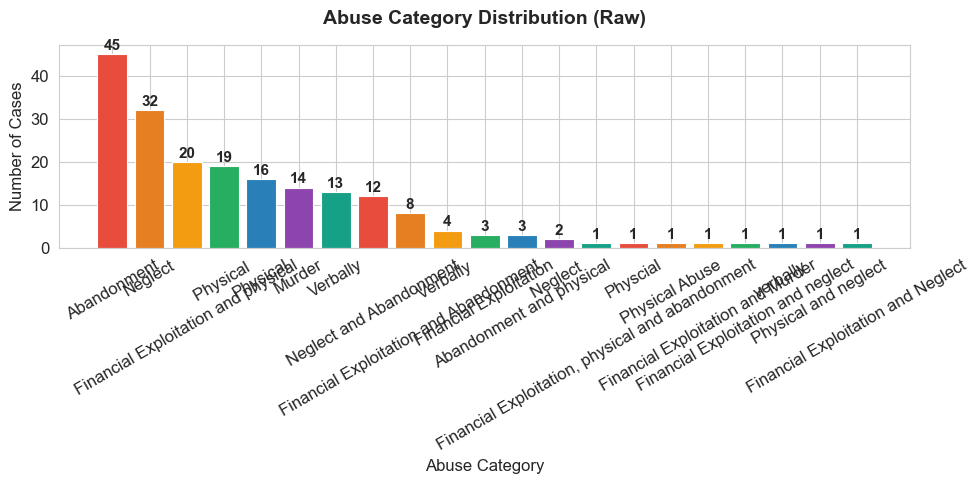

Chart saved → data/chart_01_abuse_category.png ✅


In [12]:
cat_col = [c for c in df.columns if 'abuse' in c.lower() and 'category' in c.lower()][0]
counts = df[cat_col].value_counts()

colors = ['#e74c3c','#e67e22','#f39c12','#27ae60','#2980b9','#8e44ad','#16a085']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=colors[:len(counts)], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Abuse Category Distribution (Raw)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Abuse Category', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/chart_01_abuse_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → data/chart_01_abuse_category.png ✅')

## Cell 13 — Chart 2: Abuser Relation (Who Abuses?)

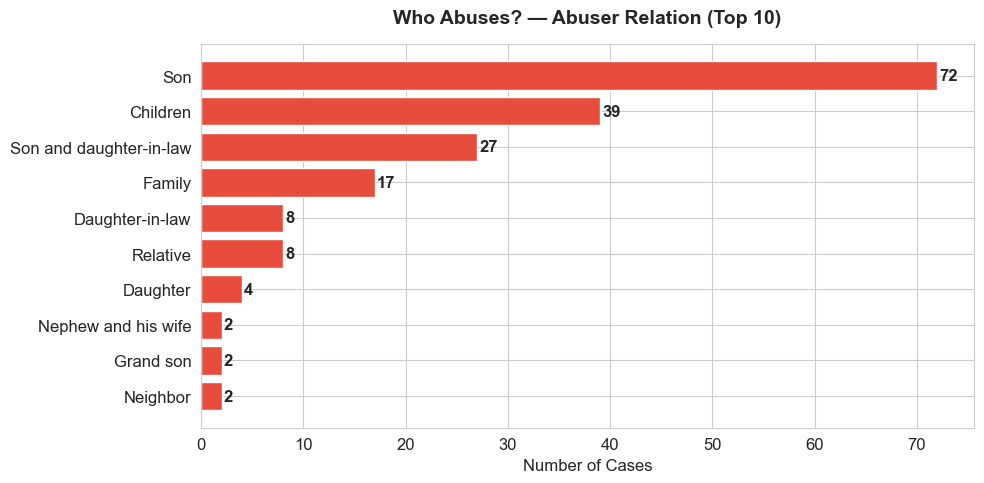

Chart saved → data/chart_02_abuser_relation.png ✅


In [13]:
rel_col = [c for c in df.columns if 'relation' in c.lower() or 'abuser' in c.lower()][0]
rel_counts = df[rel_col].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rel_counts.index[::-1], rel_counts.values[::-1],
               color='#e74c3c', edgecolor='white')

for bar, val in zip(bars, rel_counts.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Who Abuses? — Abuser Relation (Top 10)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Cases', fontsize=12)
plt.tight_layout()
plt.savefig('../data/chart_02_abuser_relation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → data/chart_02_abuser_relation.png ✅')

## Cell 14 — Chart 3: Data Source Type

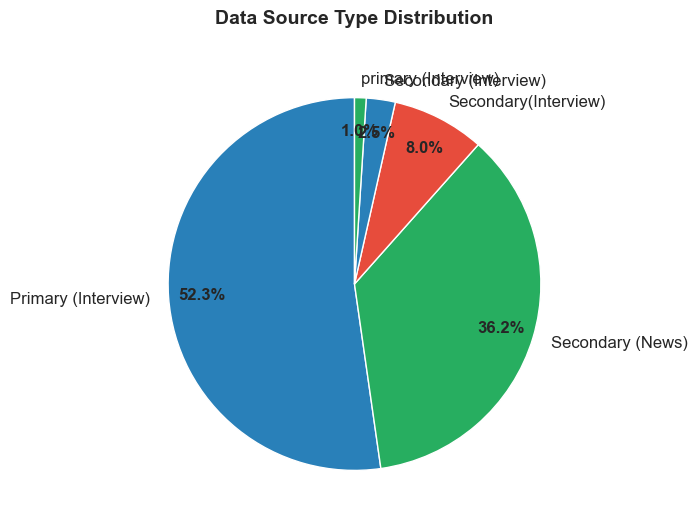

Chart saved → data/chart_03_data_source.png ✅


In [14]:
type_col = [c for c in df.columns if 'data' in c.lower() and 'type' in c.lower()][0]
type_counts = df[type_col].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = ['#2980b9', '#27ae60', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(type_counts)],
    startangle=90,
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')

ax.set_title('Data Source Type Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/chart_03_data_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → data/chart_03_data_source.png ✅')

## Cell 15 — Chart 4: Gender Distribution

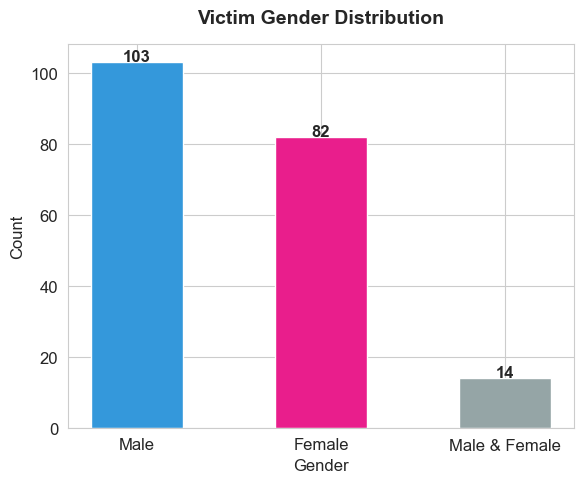

Chart saved → data/chart_04_gender.png ✅


In [15]:
gen_col = [c for c in df.columns if 'gender' in c.lower()][0]
gen_counts = df[gen_col].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(gen_counts.index, gen_counts.values,
              color=['#3498db', '#e91e8c', '#95a5a6'][:len(gen_counts)],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, gen_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold', fontsize=12)

ax.set_title('Victim Gender Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('../data/chart_04_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → data/chart_04_gender.png ✅')

## Cell 16 — Step 1 Summary

In [16]:
print('=' * 55)
print('  STEP 1 COMPLETE — Dataset Load & Initial EDA')
print('=' * 55)
print(f'  Total cases        : {len(df)}')
print(f'  Total columns      : {len(df.columns)}')

cat_col = [c for c in df.columns if 'abuse' in c.lower() and 'category' in c.lower()][0]
print(f'  Abuse categories   : {df[cat_col].nunique()} (raw, with typos)')

rel_col = [c for c in df.columns if 'relation' in c.lower() or 'abuser' in c.lower()][0]
family_kw = ['son','daughter','spouse','husband','wife','child','ছেলে','মেয়ে']
family_ct  = df[rel_col].str.lower().str.contains('|'.join(family_kw), na=False).sum()
print(f'  Trust Blind Spot   : {family_ct} cases ({family_ct/len(df)*100:.1f}% family abusers)')

missing_ct = df.isnull().sum().sum()
print(f'  Total missing vals : {missing_ct}')
print()
print('  Charts saved in data/ folder:')
print('  ✅ chart_01_abuse_category.png')
print('  ✅ chart_02_abuser_relation.png')
print('  ✅ chart_03_data_source.png')
print('  ✅ chart_04_gender.png')
print()
print('  NEXT → Step 2: Dataset Cleaning + Train/Test Split')
print('=' * 55)

  STEP 1 COMPLETE — Dataset Load & Initial EDA
  Total cases        : 199
  Total columns      : 12
  Abuse categories   : 21 (raw, with typos)
  Trust Blind Spot   : 165 cases (82.9% family abusers)
  Total missing vals : 0

  Charts saved in data/ folder:
  ✅ chart_01_abuse_category.png
  ✅ chart_02_abuser_relation.png
  ✅ chart_03_data_source.png
  ✅ chart_04_gender.png

  NEXT → Step 2: Dataset Cleaning + Train/Test Split
